=== Loaded ===
AnnData: AnnData object with n_obs × n_vars = 32374 × 7725
    obs: 'Sample', 'Patient', 'Tumor status', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'highLevelType', 'chemo'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts' | X: <class 'scipy.sparse._csr.csr_matrix'>
bulk: (7725, 12)  (genes x bulk_cols)
truep: (9, 12)  (celltypes x bulk_cols)

=== AnnData: combo groups (ALL) ===
n_combos: 6

Top 20 combos by #cells:
combo_key
s1 | P1 | Tumor | post    6821
s8 | P7 | Tumor | pre     5754
s4 | P4 | Tumor | pre     5607
s3 | P3 | Tumor | post    5166
s2 | P2 | Tumor | pre     4555
s7 | P7 | AN | pre        4471

=== QC (ALL cells) ===
        n_genes  total_counts
count  32374.00      32374.00
mean    1457.89       5053.62
std      590.03       4672.39
min      499.00        699.00
25%     1050.00       2691.00
50%     1277.00       3648.00
75%     1731.00       5578.75
max     3499

<Figure size 1000x400 with 0 Axes>

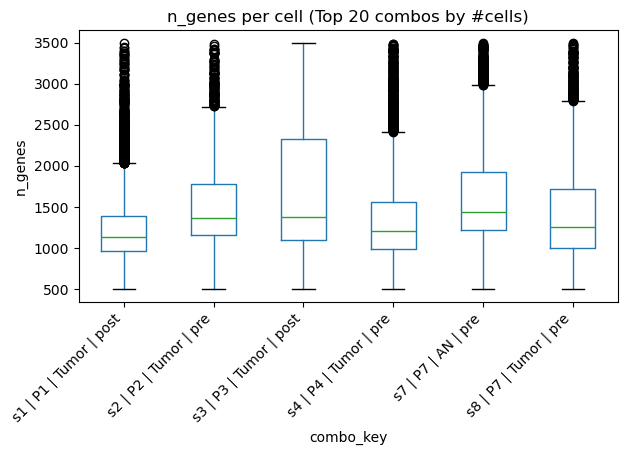

<Figure size 1000x400 with 0 Axes>

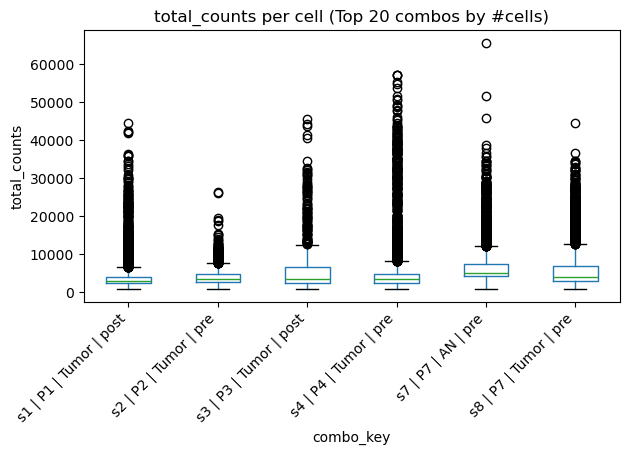

In [1]:
# Jupyter cell: Pull EVERYTHING (all samples) from AnnData + bulk + trueprops (no file saves)

AD_PATH    = r"../Dataset/train_data/train_adata.h5ad"
BULK_PATH  = r"../Dataset/train_data/train_bulk.csv"
TRUE_PATH  = r"../Dataset/train_data/train_bulk_trueprops.csv"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1) Loaders
# -------------------------
def _load_adata(path):
    try:
        import anndata as ad
    except Exception as e:
        raise RuntimeError("請先安裝 anndata：pip install anndata scanpy scipy pandas numpy") from e
    return ad.read_h5ad(path)

adata = _load_adata(AD_PATH)
bulk  = pd.read_csv(BULK_PATH, index_col=0)
truep = pd.read_csv(TRUE_PATH, index_col=0)

print("=== Loaded ===")
print("AnnData:", adata, "| X:", type(adata.X))
print("bulk:", bulk.shape, " (genes x bulk_cols)")
print("truep:", truep.shape, " (celltypes x bulk_cols)")
print()

# -------------------------
# 2) Utilities (sparse-safe)
# -------------------------
def _is_sparse(x):
    try:
        from scipy import sparse
        return sparse.issparse(x)
    except Exception:
        return False

def _sum_axis1(X):
    if _is_sparse(X):
        return np.asarray(X.sum(axis=1)).ravel()
    return np.sum(X, axis=1)

def _nnz_axis1(X):
    if _is_sparse(X):
        # CSR/CSC fast path
        if hasattr(X, "indptr"):
            return np.diff(X.indptr)
        return np.count_nonzero(X.toarray(), axis=1)
    return np.count_nonzero(X, axis=1)

def _mean_axis0(X):
    """Return dense 1D mean over axis=0."""
    m = X.mean(axis=0)
    # scipy sparse returns matrix; numpy may return ndarray
    return np.asarray(m).ravel()
# -------------------------
# 3) AnnData overview: ALL combos (Sample+Patient+Tumor status+chemo)
# -------------------------
ct_col = "highLevelType"
group_cols = ["Sample", "Patient", "Tumor status", "chemo"]

missing = [c for c in group_cols if c not in adata.obs.columns]
if missing:
    raise KeyError(f"Missing columns in adata.obs: {missing}")

if ct_col not in adata.obs.columns:
    print(f"WARNING: obs['{ct_col}'] 不存在，將跳過 cell-type signature / composition。")
    ct_col = None

obs_tmp = adata.obs.copy()
obs_tmp[group_cols] = obs_tmp[group_cols].astype(str)

SEP = " | "
obs_tmp["combo_key"] = obs_tmp[group_cols].agg(SEP.join, axis=1)

combo_counts = obs_tmp["combo_key"].value_counts().sort_values(ascending=False)

print("=== AnnData: combo groups (ALL) ===")
print("n_combos:", combo_counts.shape[0])
print("\nTop 20 combos by #cells:")
print(combo_counts.head(20).to_string())
print()

# for convenience later
combos = obs_tmp["combo_key"].astype(str)

# -------------------------
# 4) QC for ALL cells + per-combo summary + plots
# -------------------------
print("=== QC (ALL cells) ===")
if {"n_genes","total_counts"}.issubset(adata.obs.columns):
    n_genes = adata.obs["n_genes"].to_numpy()
    total_counts = adata.obs["total_counts"].to_numpy()
else:
    n_genes = _nnz_axis1(adata.X)
    total_counts = _sum_axis1(adata.X)

qc_all = pd.DataFrame({
    "combo_key": combos.values,
    "n_genes": n_genes,
    "total_counts": total_counts
})

# overall
print(qc_all[["n_genes","total_counts"]].describe().round(2).to_string())
print()

# per-combo describe (compact)
qc_by_combo = qc_all.groupby("combo_key")[["n_genes","total_counts"]].agg(
    n_cells=("n_genes","size"),
    n_genes_median=("n_genes","median"),
    n_genes_mean=("n_genes","mean"),
    total_counts_median=("total_counts","median"),
    total_counts_mean=("total_counts","mean"),
).sort_values("n_cells", ascending=False)

print("=== QC by combo_key (ALL) ===")
print(qc_by_combo.round(2).to_string())
print()

# plots: boxplot by combo (if too many combos, show top K by #cells)
TOPK = 20
top_combos = qc_by_combo.head(TOPK).index.tolist()

plt.figure(figsize=(max(10, 0.55*len(top_combos)), 4))
qc_all.loc[qc_all["combo_key"].isin(top_combos)].boxplot(column="n_genes", by="combo_key", grid=False)
plt.title(f"n_genes per cell (Top {TOPK} combos by #cells)")
plt.suptitle("")
plt.xlabel("combo_key"); plt.ylabel("n_genes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(max(10, 0.55*len(top_combos)), 4))
qc_all.loc[qc_all["combo_key"].isin(top_combos)].boxplot(column="total_counts", by="combo_key", grid=False)
plt.title(f"total_counts per cell (Top {TOPK} combos by #cells)")
plt.suptitle("")
plt.xlabel("combo_key"); plt.ylabel("total_counts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


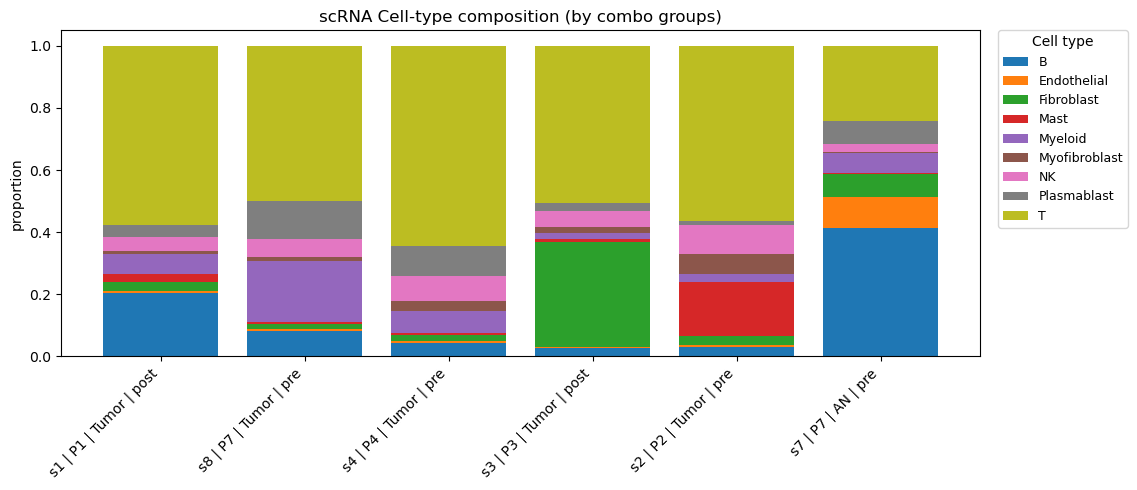

In [2]:
ct_col = "highLevelType"
cols = ["Sample", "Patient", "Tumor status", "chemo"]

# ---- safety checks ----
missing = [c for c in cols + [ct_col] if c not in adata.obs.columns]
if missing:
    raise KeyError(f"Missing columns in adata.obs: {missing}")

# ---- rebuild combo_table (ensure it matches current adata.obs) ----
combo_table = (
    adata.obs[cols]
    .astype(str)
    .drop_duplicates()
    .reset_index(drop=True)
)

# ---- build a combo key in BOTH combo_table and adata.obs ----
SEP = " | "
combo_table = combo_table.copy()
combo_table["combo_key"] = combo_table[cols].agg(SEP.join, axis=1)

obs_tmp = adata.obs.copy()
obs_tmp[cols] = obs_tmp[cols].astype(str)
obs_tmp["combo_key"] = obs_tmp[cols].agg(SEP.join, axis=1)

# ---- crosstab: rows=combo_key, cols=celltype ----
ct = obs_tmp[ct_col].astype(str)
comp_counts_combo = pd.crosstab(obs_tmp["combo_key"], ct)

# keep row order aligned to combo_table (optional, but nice)
comp_counts_combo = comp_counts_combo.reindex(combo_table["combo_key"]).fillna(0).astype(int)

# proportions
row_sums = comp_counts_combo.sum(axis=1).replace(0, np.nan)
comp_props_combo = comp_counts_combo.div(row_sums, axis=0)
# ---- plot top K combos by #cells ----
combo_sizes = comp_counts_combo.sum(axis=1).sort_values(ascending=False)
top_combos = combo_sizes.index.tolist()

comp_props_top = comp_props_combo.loc[top_combos].fillna(0.0)

plt.figure(figsize=(max(10, 0.55*len(top_combos)), 5.0))
bottom = np.zeros(comp_props_top.shape[0])

for celltype in comp_props_top.columns:
    vals = comp_props_top[celltype].values
    plt.bar(comp_props_top.index, vals, bottom=bottom, label=celltype)
    bottom += vals

plt.ylabel("proportion")
plt.title(f"scRNA Cell-type composition (by combo groups)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# 🔽 加 legend（放在圖外，避免遮擋）
plt.legend(
        title="Cell type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9
    )

plt.show()


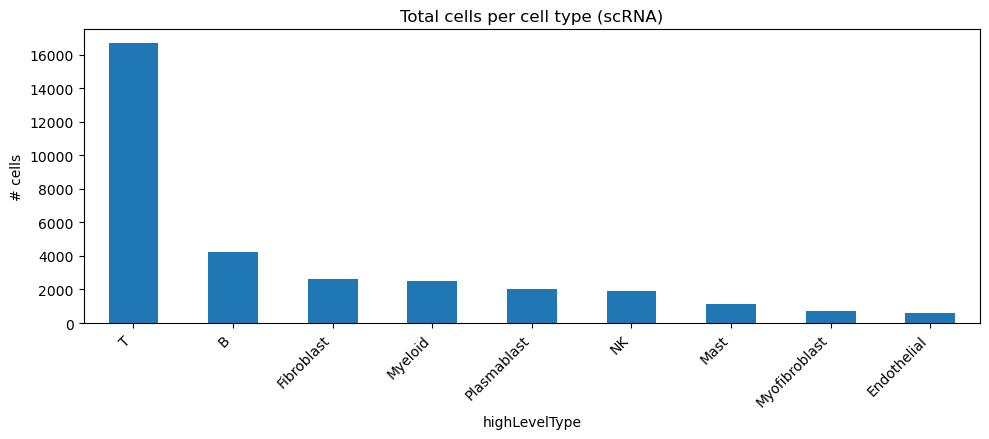

In [39]:
# 1) total cells per cell type across ALL combos (i.e., all cells)
ct_total = comp_counts_combo.sum(axis=0).sort_values(ascending=False)
plt.figure(figsize=(max(10, 0.4 * len(ct_total)), 4.5))
ct_total.plot(kind="bar")
plt.ylabel("# cells")
plt.title("Total cells per cell type (scRNA)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [18]:
# -------------------------
# 6) Build signature from ALL train cells (genes x celltypes)
# -------------------------
if ct_col:
    print("=== Signature (ALL cells): mean expression per cell type ===")
    celltypes = sorted(adata.obs[ct_col].astype(str).unique())
    sig_cols = []
    for c in celltypes:
        idx = (adata.obs[ct_col].astype(str) == c).values
        m = _mean_axis0(adata.X[idx])
        sig_cols.append(pd.Series(m, index=adata.var_names.astype(str), name=c))
    signature = pd.concat(sig_cols, axis=1)  # genes x celltypes

    print("signature shape (genes x celltypes):", signature.shape)
    print("celltypes:", celltypes)
    print("\n[signature head]")
    print(signature.head(6).round(4).to_string())
    print()

=== Signature (ALL cells): mean expression per cell type ===
signature shape (genes x celltypes): (7725, 9)
celltypes: ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']

[signature head]
                 B  Endothelial  Fibroblast    Mast  Myeloid  Myofibroblast      NK  Plasmablast       T
Unnamed: 0                                                                                              
NOC2L       0.1336       0.1603      0.1799  0.2086   0.1460         0.0904  0.1282       0.2037  0.1288
HES4        0.0833       0.2454      0.3782  1.4496   1.1307         0.4047  0.4228       0.1038  0.3209
ISG15       0.3373       0.9466      0.5208  1.5045   1.2513         0.7552  1.3333       0.5295  1.0159
TNFRSF18    0.1367       0.0801      0.0450  0.5216   0.3462         0.4117  1.0586       0.6870  1.2569
TNFRSF4     0.0793       0.1820      0.0430  0.4236   0.2988         0.3477  0.1643       0.3524  1.0488
SDF4        0.1310       0.3856

=== Bulk: library size per column (top 20) ===
s1_1    8718035.0
s7_1    6442387.0
s7_0    6304551.0
s3_0    5738087.0
s4_0    5376201.0
s1_0    5195874.0
s8_0    5099314.0
s4_1    4788627.0
s3_1    4469142.0
s2_1    4310151.0
s8_1    4286059.0
s2_0    4126009.0



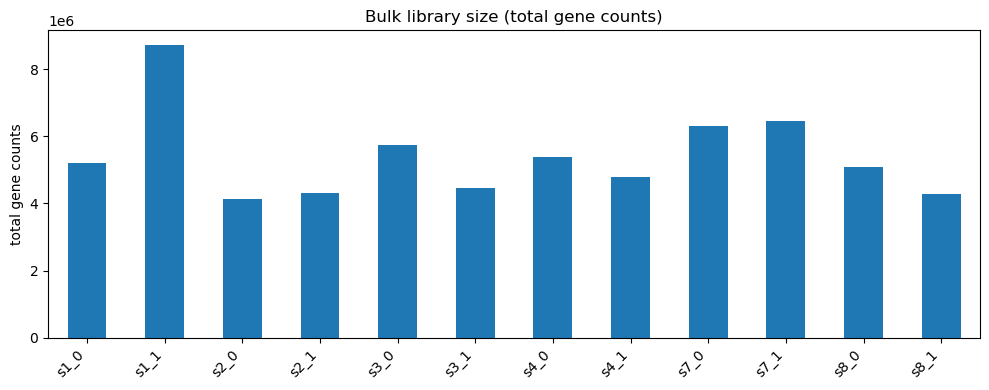

In [ ]:
# -------------------------
# 7) Bulk: group ALL columns by sample prefix + library sizes + plots
# -------------------------

# library sizes (sum of counts per bulk column)
bulk_libsize = bulk.sum(axis=0).sort_values(ascending=False)
print("=== Bulk: library size per column (top 20) ===")
print(bulk_libsize.head(20).to_string())
print()

# plot top 30 lib sizes (avoid unreadable giant plot)
plt.figure(figsize=(max(10, 0.35*len(bulk_libsize)), 4))
bulk_libsize.sort_index().plot(kind="bar")
plt.ylabel("total gene counts")
plt.title(f"Bulk library size (total gene counts)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


=== True proportions: align with bulk columns ===
bulk cols present in truep: 12 / 12


[Check sum per bulk col] (should be ~1)
s1_0    1.0
s1_1    1.0
s2_0    1.0
s2_1    1.0
s3_0    1.0
s3_1    1.0
s4_0    1.0
s4_1    1.0
s7_0    1.0
s7_1    1.0
s8_0    1.0
s8_1    1.0



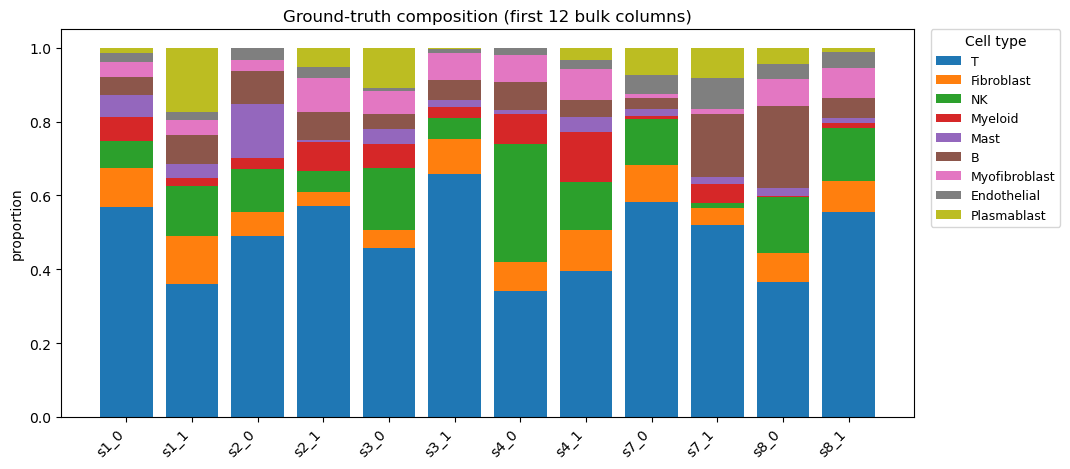

In [44]:

# -------------------------
# 8) True proportions: align ALL available bulk cols + checks + plot
# -------------------------
all_bulk_cols = list(bulk.columns.astype(str))

print("=== True proportions: align with bulk columns ===")
true_cols = [c for c in all_bulk_cols if c in set(truep.columns.astype(str))]
missing_in_truep = [c for c in all_bulk_cols if c not in set(truep.columns.astype(str))]

print("bulk cols present in truep:", len(true_cols), "/", len(all_bulk_cols))
if missing_in_truep:
    print("missing in truep (first 20):", missing_in_truep[:20])
print()

if true_cols:
    tp_all = truep.loc[:, true_cols]
    # sum check per column
    tp_sum = tp_all.sum(axis=0)
    print("\n[Check sum per bulk col] (should be ~1)")
    print(tp_sum.round(6).head(20).to_string())
    print()

    # plot stacked bars for first N bulk columns (too many columns will be unreadable)
    N_PLOT = min(12, tp_all.shape[1])
    cols_plot = tp_all.columns[:N_PLOT].tolist()

    plt.figure(figsize=(max(8, 0.9*N_PLOT), 4.8))
    bottom = np.zeros(len(cols_plot))

    for celltype in tp_all.index.astype(str):
        vals = tp_all.loc[celltype, cols_plot].values
        plt.bar(cols_plot, vals, bottom=bottom, label=celltype)
        bottom += vals

    plt.ylabel("proportion")
    plt.title(f"Ground-truth composition (first {N_PLOT} bulk columns)")
    plt.xticks(rotation=45, ha="right")

    # 🔽 加 legend（放在圖外，避免遮擋）
    plt.legend(
        title="Cell type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\scanpy\preprocessing\_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


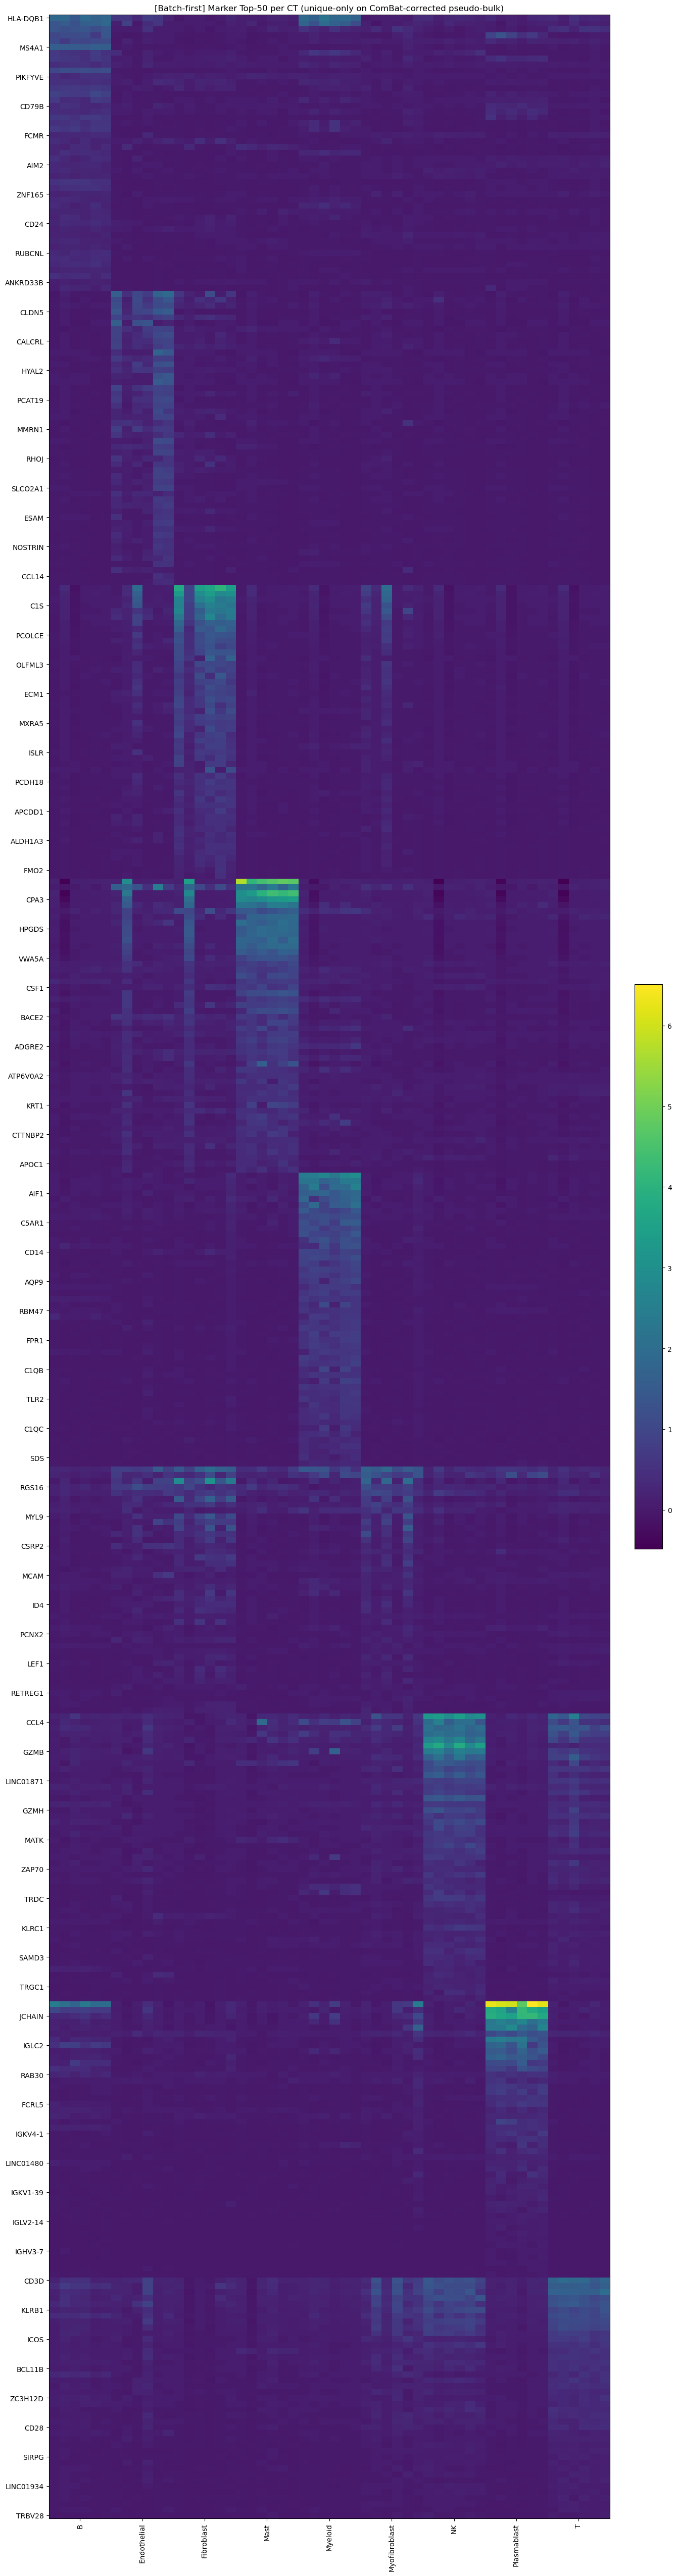

[CTs] ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']
[Removed cross-CT duplicates] 12 genes
  - B: kept 47 genes
  - Endothelial: kept 50 genes
  - Fibroblast: kept 50 genes
  - Mast: kept 50 genes
  - Myeloid: kept 50 genes
  - Myofibroblast: kept 42 genes
  - NK: kept 49 genes
  - Plasmablast: kept 47 genes
  - T: kept 41 genes
[Total rows plotted] 426


In [ ]:
# Jupyter cell: Batch-first marker selection (on ComBat-corrected pseudo-bulk) → unique-only Top-50/CT → one big heatmap
AD_PATH       = r"../train_data/train_adata.h5ad"
CELLTYPE_COL  = "highLevelType"   # fallback: 'cell_type'
SAMPLE_COL    = "Sample"
TOP_K         = 50
USE_COMBAT    = True              # 先校正再選 marker：True 開啟 ComBat (batch=Sample)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- helpers ----------------
def _need_scanpy():
    import scanpy as sc
    return sc

def _preprocess(adata):
    sc = _need_scanpy()
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

def _pseudobulk_sample_ct(adata, ct_col: str, sample_col: str) -> pd.DataFrame:
    # genes × (sample|ct)
    obs = adata.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        X = adata.X[idx]
        cols.append(np.asarray(X.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=adata.var_names.astype(str), columns=names)

def _combat(pb: pd.DataFrame) -> pd.DataFrame:
    # ComBat on pseudo-bulk (batch = Sample)
    sc = _need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def _contrast_topk(pb: pd.DataFrame, top_k: int) -> dict:
    """
    用已 batch-correct 的 pseudo-bulk 計對比分數：
      score(g, ct) = log2( mean_pb[g, ct] / mean_pb[g, rest] )
    取每個 CT 的 Top-K 基因；回傳 {ct: [genes...]}
    """
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    mean_all = pb.mean(axis=1) + 1e-9
    out = {}
    for ct in cts:
        cols_ct = [c for c in pb.columns if c.split("|",1)[1] == ct]
        if not cols_ct:
            out[ct] = []
            continue
        m_ct = pb[cols_ct].mean(axis=1)
        # rest = 加權方式：其他 CT 的均值（避免除以 0）
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct + 1e-9) / (rest + 1e-9))
        out[ct] = list(score.sort_values(ascending=False).index[:top_k])
    return out

def _row_zscore(M: np.ndarray) -> np.ndarray:
    mu = M.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd[sd == 0] = 1.0
    return (M - mu) / sd

# ---------------- pipeline ----------------
sc = _need_scanpy()
adata = sc.read_h5ad(AD_PATH)
if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("Missing cell-type column (highLevelType/cell_type).")
if SAMPLE_COL not in adata.obs:
    raise KeyError("Missing 'Sample' column in adata.obs.")

_preprocess(adata)

# 1) pseudo-bulk
pb = _pseudobulk_sample_ct(adata, CELLTYPE_COL, SAMPLE_COL)

# 2) 先做 batch 校正（Sample 為 batch）
if USE_COMBAT:
    pb = _combat(pb)

# 3) 在校正後的 pseudo-bulk 上選 marker（CT vs rest, logFC Top-K/CT）
ct_to_top = _contrast_topk(pb, TOP_K)

# 4) 移除出現在 ≥2 個 CT Top-K 名單的基因（unique-only 規則）
from collections import Counter
gene_counts = Counter(g for genes in ct_to_top.values() for g in genes)
dup_genes = {g for g, n in gene_counts.items() if n >= 2}
ct_to_unique = {ct: [g for g in genes if g not in dup_genes] for ct, genes in ct_to_top.items()}

# 5) 欄排序（按 CT 分組），列排序（各 CT 的 unique genes 依全欄平均降冪，串接）
cts = sorted({c.split("|",1)[1] for c in pb.columns})
ct_to_cols = {ct: [c for c in pb.columns if c.split("|",1)[1] == ct] for ct in cts}
row_global_mean = pb.mean(axis=1)

row_order_concat = []
ct_sizes_kept = {}
for ct in cts:
    uniq = [g for g in ct_to_unique.get(ct, []) if g in pb.index]
    uniq_sorted = sorted(uniq, key=lambda g: row_global_mean.loc[g], reverse=True)
    if uniq_sorted:
        row_order_concat.extend(uniq_sorted)
    ct_sizes_kept[ct] = len(uniq_sorted)

if len(row_order_concat) == 0:
    raise ValueError("No genes remain after duplicate-removal; lower TOP_K or allow duplicates.")

ordered_cols, group_ticks, group_labels = [], [], []
pos = 0
for ct in cts:
    cols_ct = ct_to_cols[ct]
    if not cols_ct: continue
    ordered_cols.extend(cols_ct)
    group_ticks.append(pos + (len(cols_ct)-1)/2)
    group_labels.append(ct)
    pos += len(cols_ct)

M = pb.loc[row_order_concat, ordered_cols]
Z = _row_zscore(M.values)

# 6) 畫圖
plt.figure(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.12*M.shape[0])))
im = plt.imshow(Z, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=group_ticks, labels=group_labels, rotation=90)
if M.shape[0] <= 80:
    plt.yticks(ticks=np.arange(M.shape[0]), labels=M.index)
else:
    step = max(1, M.shape[0] // 80)
    plt.yticks(ticks=np.arange(0, M.shape[0], step), labels=M.index[0::step])
plt.title(f"[Batch-first] Marker Top-{TOP_K} per CT (unique-only on ComBat-corrected pseudo-bulk)")
plt.tight_layout(); plt.show()

# 7) 簡報
print(f"[CTs] {cts}")
print(f"[Removed cross-CT duplicates] {len(dup_genes)} genes")
for ct in cts:
    print(f"  - {ct}: kept {ct_sizes_kept.get(ct, 0)} genes")
print(f"[Total rows plotted] {len(row_order_concat)}")


In [1]:
# file: scripts/markers_fast_robust.py
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

EPS = 1e-9

# ---------------- weights: 每個 Sample|CT 的 cell 數 ----------------
def make_weights_from_adata(adata, sample_col: str, ct_col: str) -> pd.Series:
    key = adata.obs[sample_col].astype(str) + "|" + adata.obs[ct_col].astype(str)
    cnt = key.value_counts()
    return cnt  # index: "Sample|CT"

# ---------------- 加權 Cohen's d（向量化，超快） ----------------
def weighted_cohens_d(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
    """
    X: (n_samples, n_genes), y: {0,1}, w: sample_weight >=0
    回傳 d 向量（每個基因一個值）；只用樣本層級統計，考慮不平衡。
    """
    w = np.asarray(w, float)
    X = np.asarray(X, float)
    y = np.asarray(y, int)

    w1 = w * (y == 1)
    w0 = w * (y == 0)
    s1 = w1.sum() + EPS
    s0 = w0.sum() + EPS

    # 加權均值
    mu1 = (w1[:, None] * X).sum(0) / s1
    mu0 = (w0[:, None] * X).sum(0) / s0

    # 加權變異（unbiased-ish）
    v1 = (w1[:, None] * (X - mu1) ** 2).sum(0) / s1
    v0 = (w0[:, None] * (X - mu0) ** 2).sum(0) / s0

    # 合併標準差（Hedges g 簡化）
    sp = np.sqrt((v1 + v0) / 2.0 + EPS)
    d = (mu1 - mu0) / sp
    return d

# ---------------- 主流程：超快穩健 marker 選擇 ----------------
def fast_robust_markers(
    pb: pd.DataFrame,
    top_k: int,
    weights: Optional[pd.Series] = None,
    use_standardize: bool = True,
    C: float = 1.0,
    l1_ratio: Optional[float] = None,  # None → pure L1；可設 0.5 做 elastic net
    random_state: int = 42
) -> Dict[str, List[str]]:
    """
    免調參、考慮不平衡的快速 marker 選擇：
    - 加權 Cohen's d（CT vs REST，向量化）
    - L1-Logistic(saga) + class_weight='balanced'（樣本權重與類別權重同時考慮）
    - 分數融合：rank(d正向) 與 rank(coef正向) 的平均

    回傳 {ct: topK 基因list}
    """
    # 權重向量
    if weights is None:
        weights = pd.Series(1.0, index=pb.columns, dtype=float)
    else:
        weights = weights.reindex(pb.columns).fillna(0.0).astype(float)

    X = pb.T.to_numpy(dtype=float)  # (n_samples, n_genes)
    genes = pb.index.to_numpy(str)
    col_ct = np.array([c.split("|", 1)[1] for c in pb.columns], dtype=object)
    cts = sorted(set(col_ct))

    # 標準化（Logistic 對尺度敏感；同時讓係數可比）
    scaler = StandardScaler(with_mean=True, with_std=True) if use_standardize else None
    Xz = scaler.fit_transform(X) if scaler is not None else X

    out: Dict[str, List[str]] = {}
    for ct in cts:
        y = (col_ct == ct).astype(int)
        sw = weights.values.astype(float)

        # 1) 加權 Cohen's d
        d = weighted_cohens_d(Xz, y, sw)  # 向量化

        # 2) L1 / Elastic-net Logistic（平衡類別 + 樣本權重）
        if l1_ratio is None:
            clf = LogisticRegression(
                penalty="l1", solver="saga", C=C, max_iter=2000, n_jobs=-1,
                class_weight="balanced", random_state=random_state
            )
        else:
            clf = LogisticRegression(
                penalty="elasticnet", l1_ratio=l1_ratio, solver="saga",
                C=C, max_iter=2000, n_jobs=-1, class_weight="balanced",
                random_state=random_state
            )
        clf.fit(Xz, y, sample_weight=sw)
        coef = clf.coef_.ravel()  # 正類方向

        # 3) 只取「上調」：d>0 且 coef>0
        pos = (d > 0) & (coef > 0)
        if not np.any(pos):
            # 若沒正向基因，退化為 d 排序
            order = np.argsort(-d)
            out[ct] = [g for g in genes[order][:top_k]]
            continue

        # 4) 分數融合（秩標準化避免尺度問題）
        def ranknorm(v):
            r = v.argsort().argsort().astype(float)  # 0..n-1
            return (r + 1.0) / (len(r) + 1.0)

        s = np.zeros_like(d)
        s[pos] = 0.5 * ranknorm(d[pos]) + 0.5 * ranknorm(coef[pos])

        order = np.argsort(-s)
        sel = order[:top_k]
        out[ct] = genes[sel].tolist()

    return out

# ---------------- Heatmap：CT 加權平均 → row z-score ----------------
def build_marker_heatmap_matrix(
    pb: pd.DataFrame,
    markers_by_ct: Dict[str, List[str]],
    weights: Optional[pd.Series] = None
) -> Tuple[np.ndarray, List[str], List[str]]:
    col_ct = pd.Index([c.split("|", 1)[1] for c in pb.columns], name="CT")
    cts = sorted(set(col_ct))
    if weights is None:
        weights = pd.Series(1.0, index=pb.columns, dtype=float)
    else:
        weights = weights.reindex(pb.columns).fillna(0.0).astype(float)

    row_genes: List[str] = []
    for ct in markers_by_ct:
        for g in markers_by_ct[ct]:
            if g not in row_genes and g in pb.index:
                row_genes.append(g)
    if not row_genes:
        raise ValueError("No markers found in pb.")

    sub = pb.loc[row_genes]
    M = np.zeros((len(row_genes), len(cts)), float)
    for j, ct in enumerate(cts):
        cols = [col for col, cc in zip(pb.columns, col_ct) if cc == ct]
        if not cols: continue
        w = weights.loc[cols].to_numpy(float)
        X = sub[cols].to_numpy(float)
        M[:, j] = (X @ w) / (w.sum() + EPS)

    mu = M.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd = np.where(sd < 1e-9, 1.0, sd)
    Mz = (M - mu) / sd
    return Mz, row_genes, cts

def plot_marker_heatmap(M: np.ndarray, row_genes: List[str], col_cts: List[str], title: str):
    fig, ax = plt.subplots(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.14*M.shape[0])))
    im = ax.imshow(M, aspect="auto", interpolation="nearest")
    ax.set_xticks(range(len(col_cts))); ax.set_xticklabels(col_cts, rotation=45, ha="right")
    ax.set_yticks(range(len(row_genes)))
    if len(row_genes) <= 80:
        ax.set_yticklabels(row_genes, fontsize=8)
    else:
        step = max(1, len(row_genes)//80)
        ax.set_yticks(range(0, len(row_genes), step))
        ax.set_yticklabels([row_genes[i] for i in range(0, len(row_genes), step)], fontsize=7)
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("row z-score")
    plt.tight_layout(); plt.show()


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\scanpy\preprocessing\_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


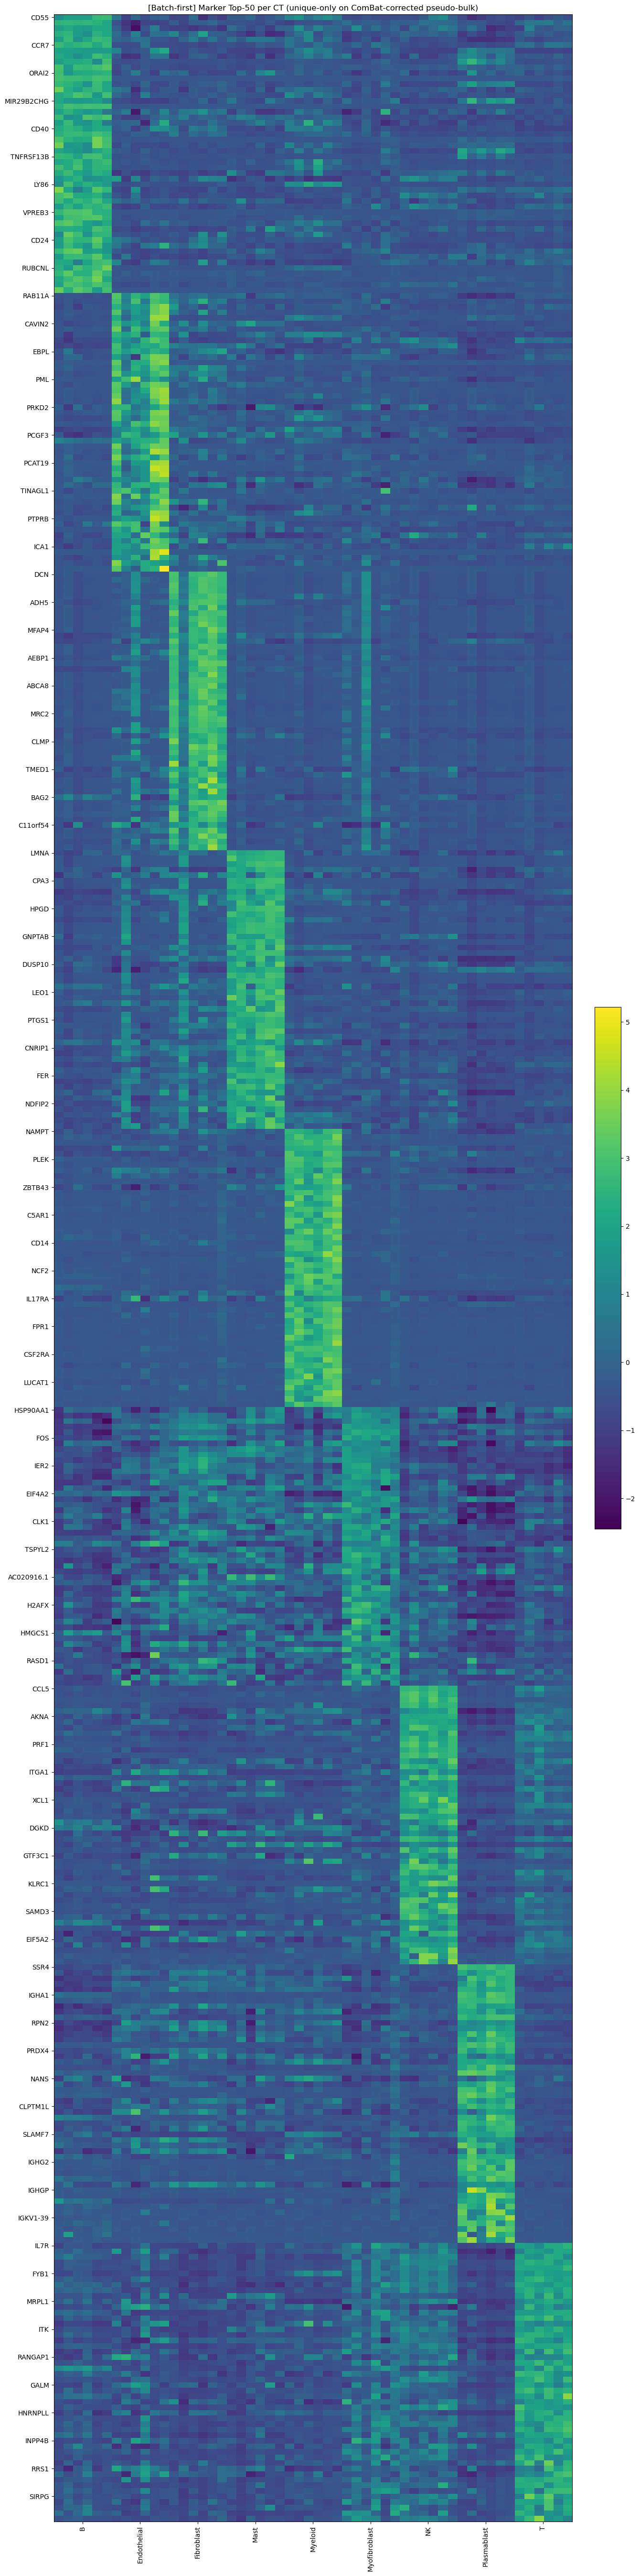

[CTs] ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']
[Removed cross-CT duplicates] 0 genes
  - B: kept 50 genes
  - Endothelial: kept 50 genes
  - Fibroblast: kept 50 genes
  - Mast: kept 50 genes
  - Myeloid: kept 50 genes
  - Myofibroblast: kept 50 genes
  - NK: kept 50 genes
  - Plasmablast: kept 50 genes
  - T: kept 50 genes
[Total rows plotted] 450


In [ ]:
# Jupyter cell: Batch-first marker selection (on ComBat-corrected pseudo-bulk) → unique-only Top-50/CT → one big heatmap
AD_PATH       = r"../train_data/train_adata.h5ad"
CELLTYPE_COL  = "highLevelType"   # fallback: 'cell_type'
SAMPLE_COL    = "Sample"
TOP_K         = 50
USE_COMBAT    = True              # 先校正再選 marker：True 開啟 ComBat (batch=Sample)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- helpers ----------------
def _need_scanpy():
    import scanpy as sc
    return sc

def _preprocess(adata):
    sc = _need_scanpy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

def _pseudobulk_sample_ct(adata, ct_col: str, sample_col: str) -> pd.DataFrame:
    # genes × (sample|ct)
    obs = adata.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        X = adata.X[idx]
        cols.append(np.asarray(X.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=adata.var_names.astype(str), columns=names)

def _combat(pb: pd.DataFrame) -> pd.DataFrame:
    # ComBat on pseudo-bulk (batch = Sample)
    sc = _need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def _contrast_topk(pb: pd.DataFrame, top_k: int) -> dict:
    """
    用已 batch-correct 的 pseudo-bulk 計對比分數：
      score(g, ct) = log2( mean_pb[g, ct] / mean_pb[g, rest] )
    取每個 CT 的 Top-K 基因；回傳 {ct: [genes...]}
    """
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    mean_all = pb.mean(axis=1) + 1e-9
    out = {}
    for ct in cts:
        cols_ct = [c for c in pb.columns if c.split("|",1)[1] == ct]
        if not cols_ct:
            out[ct] = []
            continue
        m_ct = pb[cols_ct].mean(axis=1)
        # rest = 加權方式：其他 CT 的均值（避免除以 0）
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct + 1e-9) / (rest + 1e-9))
        out[ct] = list(score.sort_values(ascending=False).index[:top_k])
    return out

def _row_zscore(M: np.ndarray) -> np.ndarray:
    mu = M.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd[sd == 0] = 1.0
    return (M - mu) / sd

# ---------------- pipeline ----------------
sc = _need_scanpy()
adata = sc.read_h5ad(AD_PATH)
if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("Missing cell-type column (highLevelType/cell_type).")
if SAMPLE_COL not in adata.obs:
    raise KeyError("Missing 'Sample' column in adata.obs.")

_preprocess(adata)

# 1) pseudo-bulk
pb = _pseudobulk_sample_ct(adata, CELLTYPE_COL, SAMPLE_COL)

# 2) 先做 batch 校正（Sample 為 batch）
if USE_COMBAT:
    pb = _combat(pb)

# 3) 在校正後的 pseudo-bulk 上選 marker（CT vs rest, logFC Top-K/CT）
weights = make_weights_from_adata(adata, sample_col=SAMPLE_COL, ct_col=CELLTYPE_COL)
ct_to_top = fast_robust_markers(
    pb=pb,
    top_k=TOP_K,
    weights=weights,          # 考慮不平衡
    use_standardize=True,     # 建議 True
    C=1.0,                    # 不調參也很穩；要更稀疏可降 C 或設 l1_ratio=0.5
    l1_ratio=None,            # None=純 L1；可改 0.5 為 elastic-net
    random_state=42
)
# 4) 移除出現在 ≥2 個 CT Top-K 名單的基因（unique-only 規則）
from collections import Counter
gene_counts = Counter(g for genes in ct_to_top.values() for g in genes)
dup_genes = {g for g, n in gene_counts.items() if n >= 2}
ct_to_unique = {ct: [g for g in genes if g not in dup_genes] for ct, genes in ct_to_top.items()}

# 5) 欄排序（按 CT 分組），列排序（各 CT 的 unique genes 依全欄平均降冪，串接）
cts = sorted({c.split("|",1)[1] for c in pb.columns})
ct_to_cols = {ct: [c for c in pb.columns if c.split("|",1)[1] == ct] for ct in cts}
row_global_mean = pb.mean(axis=1)

row_order_concat = []
ct_sizes_kept = {}
for ct in cts:
    uniq = [g for g in ct_to_unique.get(ct, []) if g in pb.index]
    uniq_sorted = sorted(uniq, key=lambda g: row_global_mean.loc[g], reverse=True)
    if uniq_sorted:
        row_order_concat.extend(uniq_sorted)
    ct_sizes_kept[ct] = len(uniq_sorted)

if len(row_order_concat) == 0:
    raise ValueError("No genes remain after duplicate-removal; lower TOP_K or allow duplicates.")

ordered_cols, group_ticks, group_labels = [], [], []
pos = 0
for ct in cts:
    cols_ct = ct_to_cols[ct]
    if not cols_ct: continue
    ordered_cols.extend(cols_ct)
    group_ticks.append(pos + (len(cols_ct)-1)/2)
    group_labels.append(ct)
    pos += len(cols_ct)

M = pb.loc[row_order_concat, ordered_cols]
Z = _row_zscore(M.values)

# 6) 畫圖
plt.figure(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.12*M.shape[0])))
im = plt.imshow(Z, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=group_ticks, labels=group_labels, rotation=90)
if M.shape[0] <= 80:
    plt.yticks(ticks=np.arange(M.shape[0]), labels=M.index)
else:
    step = max(1, M.shape[0] // 80)
    plt.yticks(ticks=np.arange(0, M.shape[0], step), labels=M.index[0::step])
plt.title(f"[Batch-first] Marker Top-{TOP_K} per CT (unique-only on ComBat-corrected pseudo-bulk)")
plt.tight_layout(); plt.show()

# 7) 簡報
print(f"[CTs] {cts}")
print(f"[Removed cross-CT duplicates] {len(dup_genes)} genes")
for ct in cts:
    print(f"  - {ct}: kept {ct_sizes_kept.get(ct, 0)} genes")
print(f"[Total rows plotted] {len(row_order_concat)}")


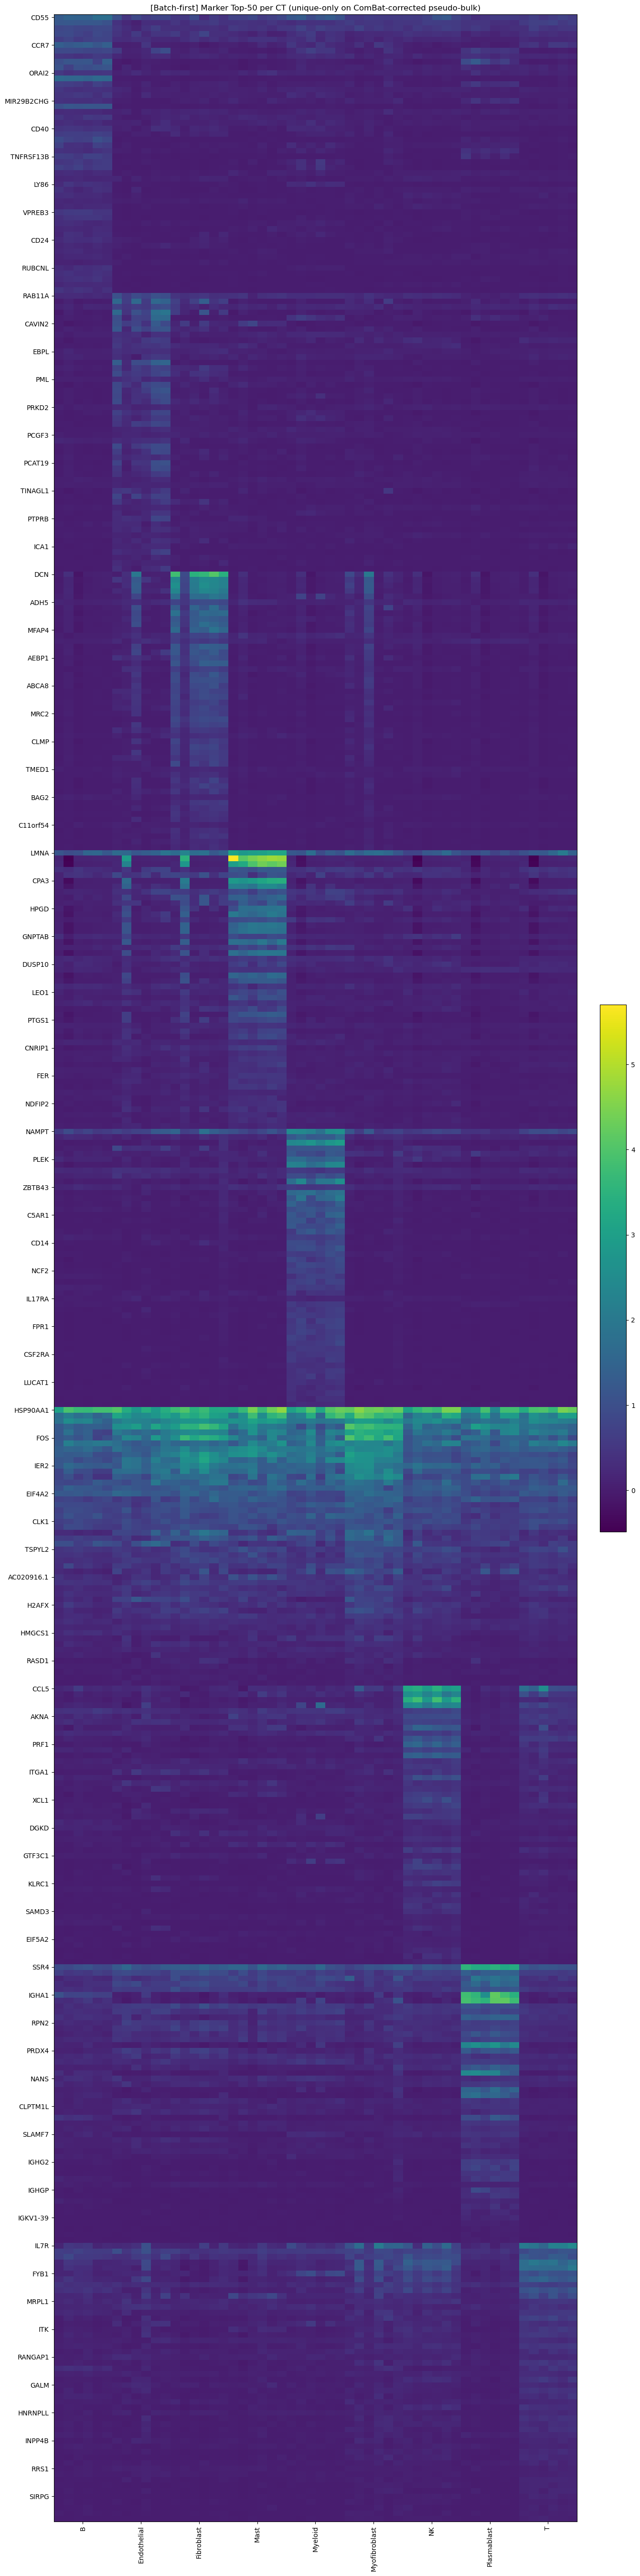

[CTs] ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']
[Removed cross-CT duplicates] 0 genes
  - B: kept 50 genes
  - Endothelial: kept 50 genes
  - Fibroblast: kept 50 genes
  - Mast: kept 50 genes
  - Myeloid: kept 50 genes
  - Myofibroblast: kept 50 genes
  - NK: kept 50 genes
  - Plasmablast: kept 50 genes
  - T: kept 50 genes
[Total rows plotted] 450


In [3]:

# 6) 畫圖
plt.figure(figsize=(max(10, 0.25*M.shape[1]), max(6, 0.12*M.shape[0])))
im = plt.imshow(M.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=group_ticks, labels=group_labels, rotation=90)
if M.shape[0] <= 80:
    plt.yticks(ticks=np.arange(M.shape[0]), labels=M.index)
else:
    step = max(1, M.shape[0] // 80)
    plt.yticks(ticks=np.arange(0, M.shape[0], step), labels=M.index[0::step])
plt.title(f"[Batch-first] Marker Top-{TOP_K} per CT (unique-only on ComBat-corrected pseudo-bulk)")
plt.tight_layout(); plt.show()

# 7) 簡報
print(f"[CTs] {cts}")
print(f"[Removed cross-CT duplicates] {len(dup_genes)} genes")
for ct in cts:
    print(f"  - {ct}: kept {ct_sizes_kept.get(ct, 0)} genes")
print(f"[Total rows plotted] {len(row_order_concat)}")


In [15]:
# --- Drop-in: batch-robust contrast score for marker picking on pseudo-bulk ---

import numpy as np
import pandas as pd

def contrast_score_batch_robust(pb: pd.DataFrame, ct: str) -> pd.Series:
    """
    批次魯棒版對比分數：
    1) 對每個 sample，將該 sample 內所有 CT 欄在「每個基因」上做中心化（減去該 sample 對應列的均值）
       => 移除 sample-level shift（批次偏移），保留 CT 間相對差異。
    2) 在中心化後矩陣上，計算 mean_ct - mean_rest（或 logFC；這裡用差值更穩）。
    只用於「選 marker」，不要把這個中心化後的矩陣拿去建最終的 S。
    """
    # 1) 解析 sample 與 ct
    samples = [c.split("|",1)[0] for c in pb.columns]
    cts      = [c.split("|",1)[1] for c in pb.columns]
    df = pb.copy()

    # 2) 逐 sample 做「基因內中心化」
    for s in sorted(set(samples)):
        cols_s = [col for col in pb.columns if col.startswith(s + "|")]
        if len(cols_s) <= 1:
            continue
        block = df[cols_s]                        # G × (#ct in this sample)
        centered = block.sub(block.mean(axis=1), axis=0)
        df[cols_s] = centered

    # 3) 在中心化矩陣上算對比分數（該 CT vs rest）
    cols_ct = [col for col in df.columns if col.endswith("|" + ct)]
    if len(cols_ct) == 0:
        return pd.Series(0.0, index=df.index)
    mean_ct   = df[cols_ct].mean(axis=1)
    other_cols= [c for c in df.columns if c not in cols_ct]
    mean_rest = df[other_cols].mean(axis=1) if other_cols else pd.Series(0.0, index=df.index)
    score = (mean_ct - mean_rest)  # 也可改成 np.log2((mean_ct+1e-9)/(mean_rest+1e-9))
    return score
